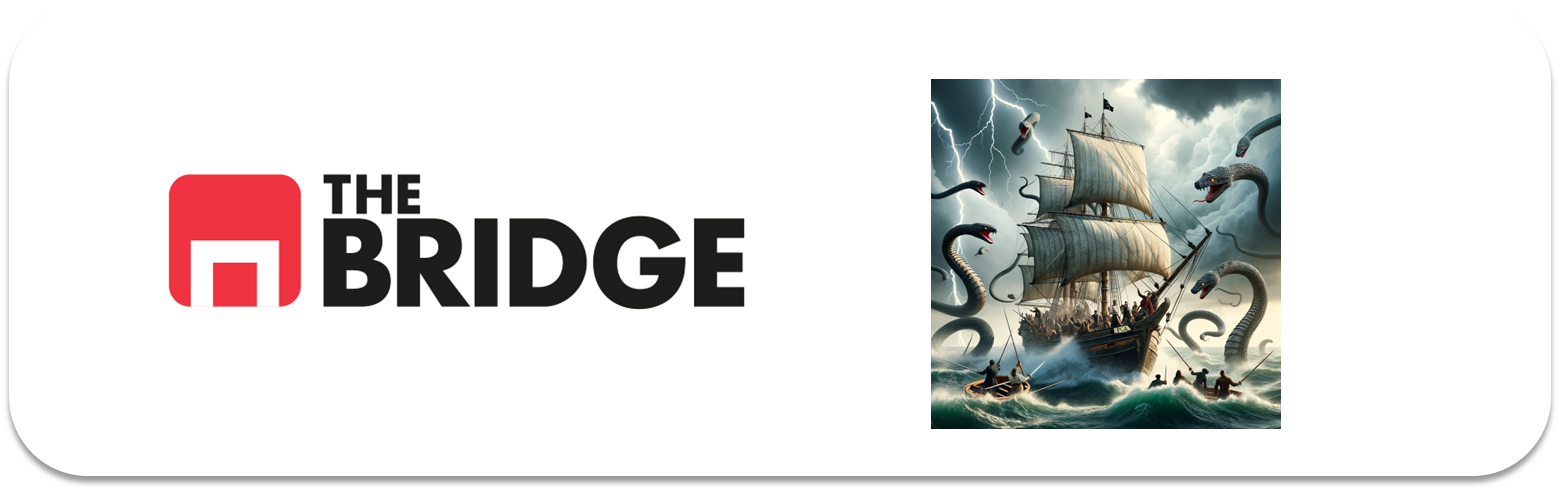

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import bootcampviztools as bvt

from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif,
    RFE, SelectFromModel, SequentialFeatureSelector
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold,
    train_test_split, GridSearchCV
)
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix,
    recall_score, roc_auc_score
)
from collections import Counter

# Reproducibilidad
SEED = 42
np.random.seed(SEED)


### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


## Paso 1 — Carga y limpieza

### Decisiones de diseño
- **Eliminamos filas con nulos**: Se pierden ~721 filas de `MonthlyIncome` y ~177 de `NumberOfDependents` → quedan **11 816 filas**.
- **Variables `NumberOf...` de impagos** (`30-59`, `60-89`, `90+`) se convierten a categóricas de **3 niveles**: 0 = ningún impago, 1 = un impago, 2 = dos o más. Valores atípicos como 98 (outliers en el raw data) quedan absorbidos en el nivel 2.
- **`NumberOfDependents`** se trata igual: 0 / 1 / 2+.
- Las variables `NumberOfOpenCreditLinesAndLoans` y `NumberRealEstateLoansOrLines` tienen un rango más continuo y se dejan numéricas.

In [2]:
# Carga
df = pd.read_csv('data/credit_npo.csv')
print(f"Tamaño original: {df.shape}")
print("Nulos por columna:")
print(df.isnull().sum())

# Eliminamos nulos
df_clean = df.dropna().copy()
print(f"\nTamaño tras dropna: {df_clean.shape}")

Tamaño original: (12537, 11)
Nulos por columna:
SeriousDlqin2yrs                          0
RevolvingUtilizationOfUnsecuredLines      0
age                                       0
NumberOfTime30-59DaysPastDueNotWorse      0
DebtRatio                                 0
MonthlyIncome                           721
NumberOfOpenCreditLinesAndLoans           0
NumberOfTimes90DaysLate                   0
NumberRealEstateLoansOrLines              0
NumberOfTime60-89DaysPastDueNotWorse      0
NumberOfDependents                      177
dtype: int64

Tamaño tras dropna: (11816, 11)


In [3]:
# Conversión de variables NumberOf... a categóricas (3 niveles)
pastdue_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]
for col in pastdue_cols:
    df_clean[col + '_cat'] = pd.cut(
        df_clean[col], bins=[-1, 0, 1, 999], labels=[0, 1, 2]
    ).astype(int)

df_clean['NumberOfDependents_cat'] = pd.cut(
    df_clean['NumberOfDependents'], bins=[-1, 0, 1, 999], labels=[0, 1, 2]
).astype(int)

# Definición de conjuntos de features
TARGET = 'SeriousDlqin2yrs'

NUM_FEATURES = [
    'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines'
]
CAT_FEATURES = [
    'NumberOfTime30-59DaysPastDueNotWorse_cat',
    'NumberOfTimes90DaysLate_cat',
    'NumberOfTime60-89DaysPastDueNotWorse_cat',
    'NumberOfDependents_cat'
]
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

X = df_clean[ALL_FEATURES]
y = df_clean[TARGET]

print("Features numéricas:", NUM_FEATURES)
print("Features categóricas:", CAT_FEATURES)
print(f"Distribución del target:\n{y.value_counts()}")
print(f"\nDesbalanceo: {y.mean()*100:.1f}% positivos (clase minoritaria)")

Features numéricas: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines']
Features categóricas: ['NumberOfTime30-59DaysPastDueNotWorse_cat', 'NumberOfTimes90DaysLate_cat', 'NumberOfTime60-89DaysPastDueNotWorse_cat', 'NumberOfDependents_cat']
Distribución del target:
SeriousDlqin2yrs
0    10986
1      830
Name: count, dtype: int64

Desbalanceo: 7.0% positivos (clase minoritaria)


## Paso 2.1 — Análisis visual + filtrado por correlación

### Por qué usamos correlación para filtrar
La correlación de Pearson (entre variables numéricas) nos indica:
1. **Colinealidad entre predictores** (correlaciones > 0.85 entre features → redundancia → candidatas a eliminar).
2. **Relación con el target** (correlación baja con el target → feature poco informativa).

Para las categóricas basta con un análisis visual de la distribución condicionada al target.

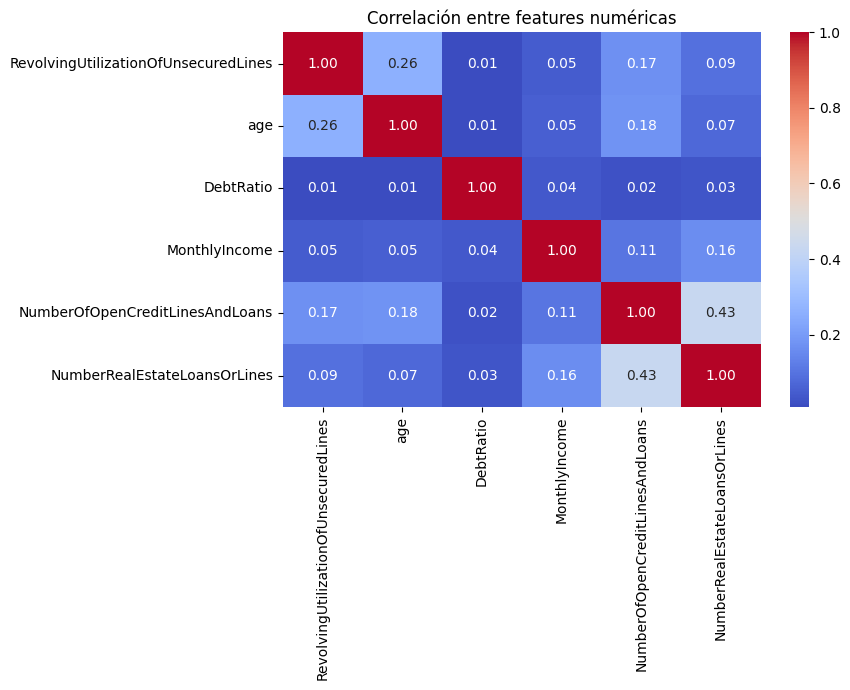

Correlación con el target (valor absoluto):
RevolvingUtilizationOfUnsecuredLines    0.2804
age                                     0.1061
NumberOfOpenCreditLinesAndLoans         0.0296
MonthlyIncome                           0.0222
DebtRatio                               0.0017
NumberRealEstateLoansOrLines            0.0013
Name: SeriousDlqin2yrs, dtype: float64

→ Umbral 0.05: features seleccionadas = ['RevolvingUtilizationOfUnsecuredLines', 'age']


In [4]:
# Matri de correlacion entre features numéricas
corr_matrix = X[NUM_FEATURES].corr().abs()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmax=1)
plt.title('Correlación entre features numéricas')
plt.tight_layout()
plt.show()

# No hay pares con correlación > 0.85 → no eliminamos por colinealidad

# Correlación de cada numérica con el target
corr_target = (
    df_clean[NUM_FEATURES + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
)
print("Correlación con el target (valor absoluto):")
print(corr_target.round(4))
print("\n→ Umbral 0.05: features seleccionadas =",
      corr_target[corr_target > 0.05].index.tolist())

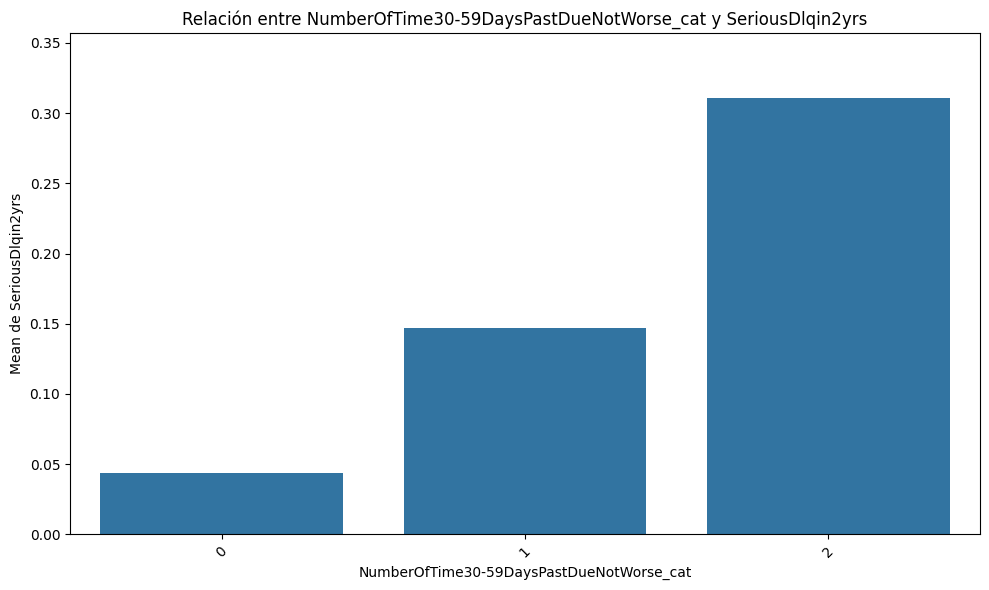

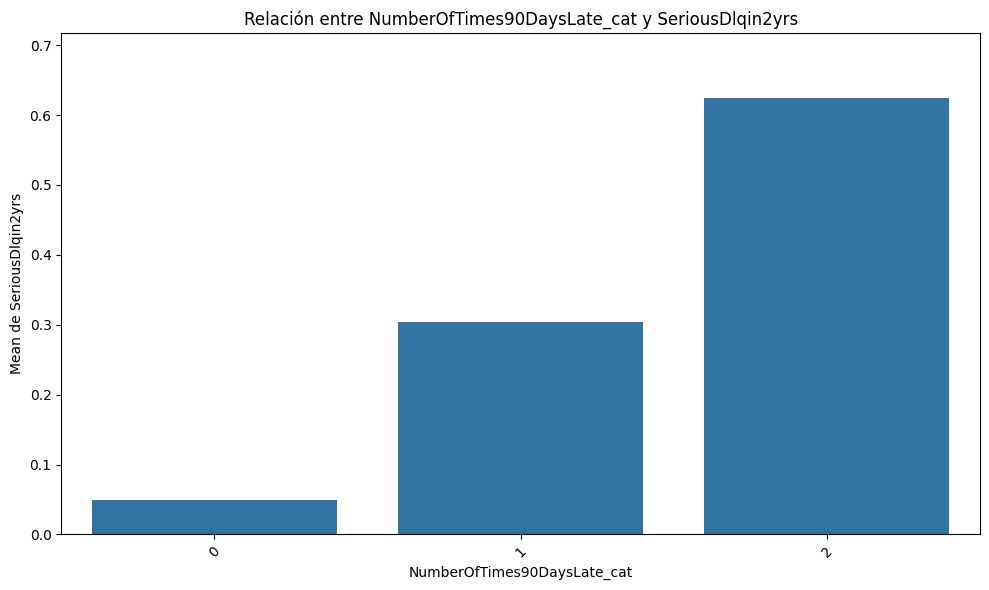

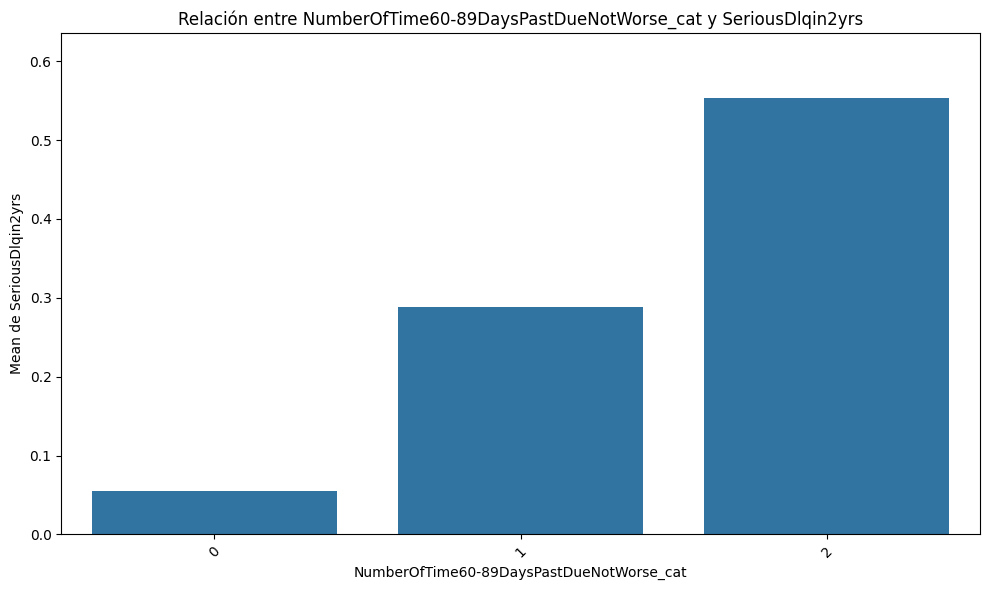

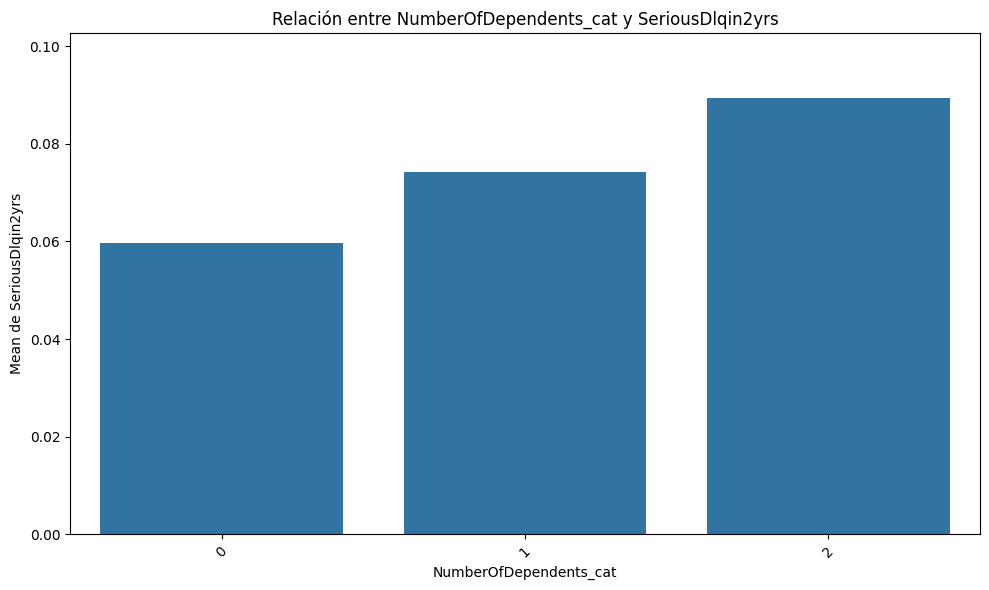

feat1 (corr + visual): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse_cat', 'NumberOfTimes90DaysLate_cat', 'NumberOfTime60-89DaysPastDueNotWorse_cat', 'NumberOfDependents_cat']


In [5]:
# % de impago por nivel de cada variable categórica 
# Usamos plot_categorical_numerical_relationship (bootcampviztools): al ser el target
# binario (0/1), la MEDIA por categoría equivale directamente al % de impago.
for col in CAT_FEATURES:
    bvt.plot_categorical_numerical_relationship(
        df_clean, categorical_col=col, numerical_col=TARGET, measure='mean'
    )

# Conclusión paso 2.1 
# RevolvingUtilization y age tienen correlación notable con el target.
# Las 3 variables de impagos (cat) muestran una clara separación visual.
feat1 = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse_cat',
    'NumberOfTimes90DaysLate_cat',
    'NumberOfTime60-89DaysPastDueNotWorse_cat',
    'NumberOfDependents_cat'
]
print("feat1 (corr + visual):", feat1)


## Paso 2.2 — SelectKBest (ANOVA) + Mutual Information

### Por qué estos métodos
- **SelectKBest + ANOVA (f_classif)**: Selecciona features basándose en el estadístico F entre cada predictor numérico y el target. Asume linealidad, pero funciona bien como primer filtro.
- **Mutual Information (mutual_info_classif)**: Mide dependencia no lineal entre variable y target. Ideal para categóricas (no asume normalidad ni linealidad).

Aplicamos ANOVA a las **numéricas** y MI a las **categóricas** por separado, para respetar la naturaleza de cada tipo.

Scores ANOVA (F):
                             feature  F_score
RevolvingUtilizationOfUnsecuredLines  1007.74
                                 age   134.45
     NumberOfOpenCreditLinesAndLoans    10.34
                       MonthlyIncome     5.82
                           DebtRatio     0.03
        NumberRealEstateLoansOrLines     0.02


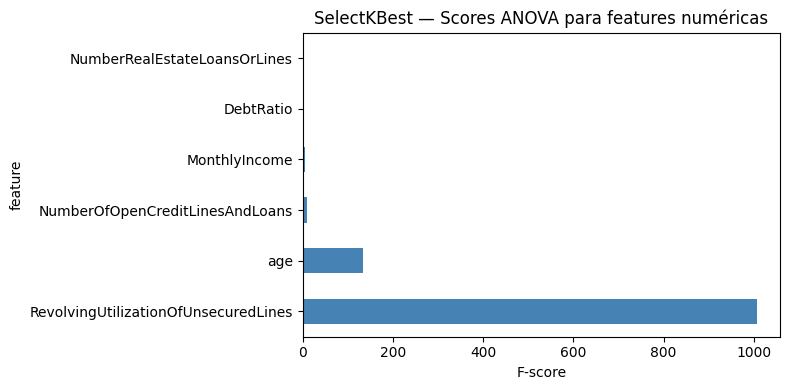


Top-4 numéricas seleccionadas: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans']


In [6]:
# ANOVA para numéricas 
skb = SelectKBest(f_classif, k=4)
skb.fit(X[NUM_FEATURES], y)
scores_df = pd.DataFrame({'feature': NUM_FEATURES, 'F_score': skb.scores_}).sort_values('F_score', ascending=False)
print("Scores ANOVA (F):")
print(scores_df.round(2).to_string(index=False))

scores_df.plot(kind='barh', x='feature', y='F_score', legend=False,
               figsize=(8, 4), color='steelblue')
plt.title('SelectKBest — Scores ANOVA para features numéricas')
plt.xlabel('F-score')
plt.tight_layout()
plt.show()

selected_num = [NUM_FEATURES[i] for i in skb.get_support(indices=True)]
print("\nTop-4 numéricas seleccionadas:", selected_num)

Mutual Information (categóricas):
                                 feature     MI
             NumberOfTimes90DaysLate_cat 0.0349
NumberOfTime30-59DaysPastDueNotWorse_cat 0.0230
NumberOfTime60-89DaysPastDueNotWorse_cat 0.0196
                  NumberOfDependents_cat 0.0012


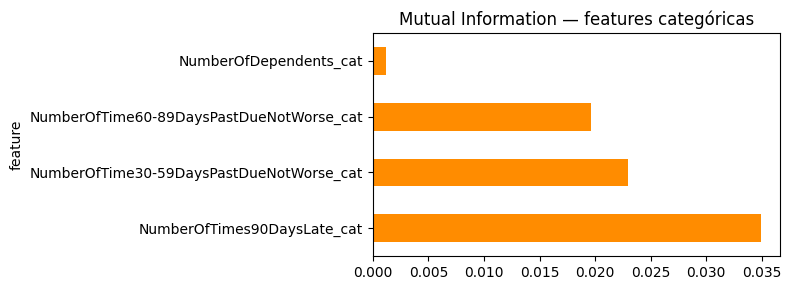


Top-2 categóricas: ['NumberOfTimes90DaysLate_cat', 'NumberOfTime30-59DaysPastDueNotWorse_cat']
 feat2 (KBest + MI): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate_cat', 'NumberOfTime30-59DaysPastDueNotWorse_cat']


In [7]:
# Mutual Information para categóricas
mi_scores = mutual_info_classif(X[CAT_FEATURES], y, discrete_features=True, random_state=SEED)
mi_df = pd.DataFrame({'feature': CAT_FEATURES, 'MI': mi_scores}).sort_values('MI', ascending=False)
print("Mutual Information (categóricas):")
print(mi_df.round(4).to_string(index=False))

mi_df.plot(kind='barh', x='feature', y='MI', legend=False,
           figsize=(8, 3), color='darkorange')
plt.title('Mutual Information — features categóricas')
plt.tight_layout()
plt.show()

selected_cat = mi_df.head(2)['feature'].tolist()
print("\nTop-2 categóricas:", selected_cat)

feat2 = list(dict.fromkeys(selected_num + selected_cat))[:6]
print(" feat2 (KBest + MI):", feat2)

## Paso 2.3 — SelectFromModel (Random Forest)

### Por qué Random Forest
- Calcula **importancias de features** basadas en la reducción de impureza (Gini/información).
- Es robusto a la escala y puede manejar mixtura de numéricas y categóricas codificadas.
- Usamos `class_weight='balanced'` para compensar el fuerte desbalanceo (solo ~7% de positivos).

Importancias RF:
RevolvingUtilizationOfUnsecuredLines        0.2712
DebtRatio                                   0.1341
MonthlyIncome                               0.1259
age                                         0.1207
NumberOfTimes90DaysLate_cat                 0.0867
NumberOfOpenCreditLinesAndLoans             0.0831
NumberOfTime30-59DaysPastDueNotWorse_cat    0.0776
NumberOfTime60-89DaysPastDueNotWorse_cat    0.0390
NumberRealEstateLoansOrLines                0.0354
NumberOfDependents_cat                      0.0264
dtype: float64


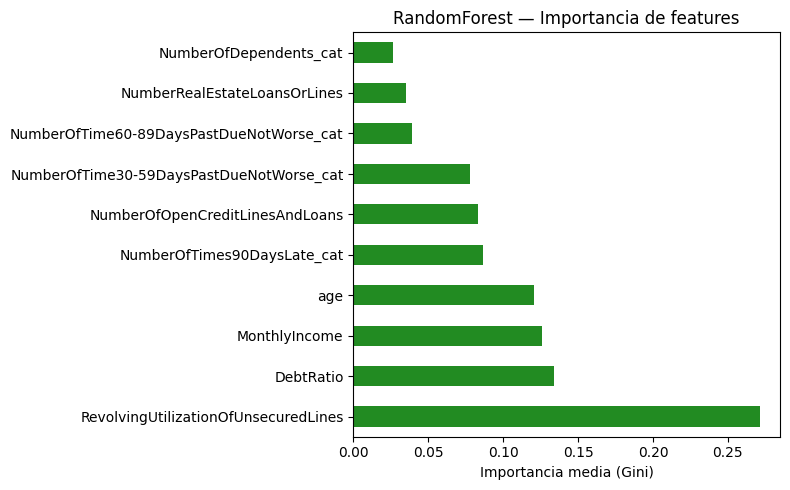


 feat3 (SelectFromModel): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome']


In [8]:
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, class_weight='balanced')
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=ALL_FEATURES).sort_values(ascending=False)
print("Importancias RF:")
print(importances.round(4))

importances.plot(kind='barh', figsize=(8, 5), color='forestgreen')
plt.title('RandomForest — Importancia de features')
plt.xlabel('Importancia media (Gini)')
plt.tight_layout()
plt.show()

sfm = SelectFromModel(rf, prefit=True, max_features=6)
feat3 = [ALL_FEATURES[i] for i in sfm.get_support(indices=True)]
print("\n feat3 (SelectFromModel):", feat3)

## Paso 2.4 — Recursive Feature Elimination (RFE)

### Por qué RFE
RFE ajusta el modelo repetidamente y elimina la feature menos importante en cada iteración. Al usar **Regresión Logística** como estimador base (escalar antes), obtenemos un ranquin basado en coeficientes lineales que complementa las importancias del árbol.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr_base = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
rfe = RFE(lr_base, n_features_to_select=6, step=1)
rfe.fit(X_scaled, y)

rfe_df = pd.DataFrame({'feature': ALL_FEATURES, 'ranking': rfe.ranking_}).sort_values('ranking')
print("RFE rankings (1 = seleccionada):")
print(rfe_df.to_string(index=False))

feat4 = [ALL_FEATURES[i] for i in range(len(ALL_FEATURES)) if rfe.support_[i]]
print("\n feat4 (RFE):", feat4)

RFE rankings (1 = seleccionada):
                                 feature  ranking
    RevolvingUtilizationOfUnsecuredLines        1
                                     age        1
NumberOfTime30-59DaysPastDueNotWorse_cat        1
            NumberRealEstateLoansOrLines        1
             NumberOfTimes90DaysLate_cat        1
NumberOfTime60-89DaysPastDueNotWorse_cat        1
         NumberOfOpenCreditLinesAndLoans        2
                           MonthlyIncome        3
                  NumberOfDependents_cat        4
                               DebtRatio        5

 feat4 (RFE): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberRealEstateLoansOrLines', 'NumberOfTime30-59DaysPastDueNotWorse_cat', 'NumberOfTimes90DaysLate_cat', 'NumberOfTime60-89DaysPastDueNotWorse_cat']


## Paso 2.5 — Sequential Feature Selection (SFS)

### Por qué SFS
SFS (forward) parte de 0 features y va añadiendo de una en una aquella que más mejora la métrica de evaluación en CV. Es un método **wrapper**: evalúa con el propio modelo objetivo (LogReg), por lo que selecciona features que realmente mejoran el rendimiento conjunto, no solo individualmente.

Usamos **recall** como scoring porque en credit scoring nos importa más detectar los impagos (falsos negativos son muy costosos).

SFS best CV recall con 6 features: 0.7518

 feat5 (SFS): ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfTime30-59DaysPastDueNotWorse_cat', 'NumberOfTime60-89DaysPastDueNotWorse_cat', 'NumberOfDependents_cat']


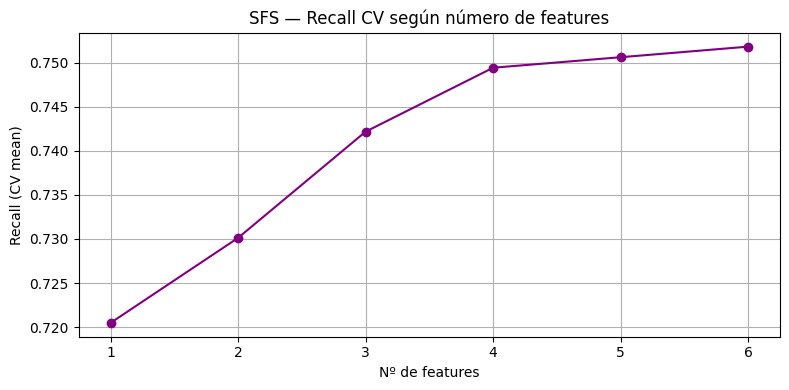

In [10]:
# SFS nativo de scikit-learn, forward, sobre LogReg
lr_sfs = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
cv_sfs = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

sfs = SequentialFeatureSelector(
    lr_sfs,
    n_features_to_select=6,
    direction='forward',
    scoring='recall',
    cv=cv_sfs,
    n_jobs=-1
)
sfs.fit(X_scaled, y)

feat5 = [ALL_FEATURES[i] for i in range(len(ALL_FEATURES)) if sfs.get_support()[i]]
best_score = cross_val_score(lr_sfs, X_scaled[:, sfs.get_support()], y, cv=cv_sfs,
                              scoring='recall', n_jobs=-1).mean()
print(f"SFS best CV recall con 6 features: {best_score:.4f}")
print("\n feat5 (SFS):", feat5)

# Curva de mejora del recall al añadir features (1 a 6)
# SequentialFeatureSelector de sklearn no guarda el histórico paso a paso (a diferencia
# de mlxtend), así que lo reconstruimos ejecutando el selector para cada tamaño.
scores_por_tam = []
for k in range(1, 7):
    sfs_k = SequentialFeatureSelector(
        lr_sfs, n_features_to_select=k, direction='forward',
        scoring='recall', cv=cv_sfs, n_jobs=-1
    )
    sfs_k.fit(X_scaled, y)
    score_k = cross_val_score(lr_sfs, X_scaled[:, sfs_k.get_support()], y, cv=cv_sfs,
                               scoring='recall', n_jobs=-1).mean()
    scores_por_tam.append(score_k)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 7), scores_por_tam, marker='o', color='purple')
plt.title('SFS — Recall CV según número de features')
plt.xlabel('Nº de features')
plt.ylabel('Recall (CV mean)')
plt.grid(True)
plt.tight_layout()
plt.show()


## Paso 2.6 — Hard Voting

### Lógica del hard voting
Unimos las 5 listas de features (pasos 2.1–2.5) y contamos cuántas veces aparece cada feature. Las features que aparecen en **3 o más métodos** son consenso y forman el conjunto final.

Esta estrategia reduce la varianza inherente a cada técnica individual: una feature que múltiples métodos independientes eligen es más robustamente relevante.

Votos por feature:
                                 feature  votes
    RevolvingUtilizationOfUnsecuredLines      5
                                     age      4
NumberOfTime30-59DaysPastDueNotWorse_cat      4
             NumberOfTimes90DaysLate_cat      3
NumberOfTime60-89DaysPastDueNotWorse_cat      3
                  NumberOfDependents_cat      2
                           MonthlyIncome      2
         NumberOfOpenCreditLinesAndLoans      2
            NumberRealEstateLoansOrLines      2
                               DebtRatio      1


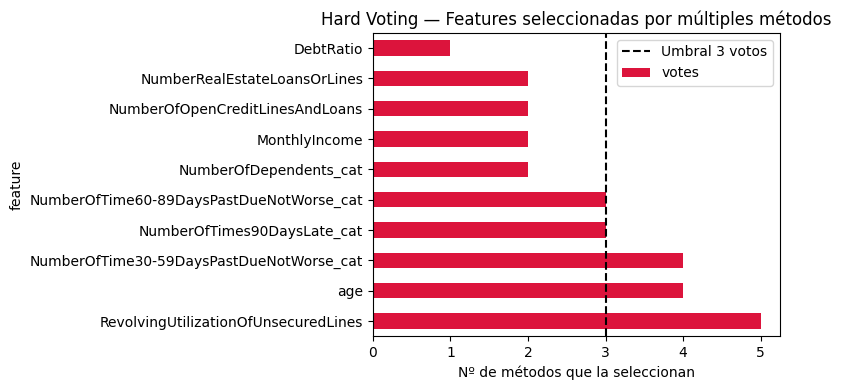


 feat6 (hard voting, ≥3 votos): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse_cat', 'NumberOfTimes90DaysLate_cat', 'NumberOfTime60-89DaysPastDueNotWorse_cat']


In [11]:
# Reutilizamos feat1..feat5, calculados en vivo en los pasos 2.1 a 2.5 anteriores
# (evitamos redefinirlos a mano para que no se puedan desincronizar del resultado real)
vote_counts = Counter(feat1 + feat2 + feat3 + feat4 + feat5)
votes_df = pd.DataFrame(vote_counts.items(), columns=['feature', 'votes']).sort_values('votes', ascending=False)
print("Votos por feature:")
print(votes_df.to_string(index=False))

votes_df.plot(kind='barh', x='feature', y='votes', legend=False,
              figsize=(8, 4), color='crimson')
plt.axvline(x=3, color='black', linestyle='--', label='Umbral 3 votos')
plt.title('Hard Voting — Features seleccionadas por múltiples métodos')
plt.xlabel('Nº de métodos que la seleccionan')
plt.legend()
plt.tight_layout()
plt.show()

feat6 = [f for f, c in vote_counts.most_common() if c >= 3][:6]
print("\n feat6 (hard voting, ≥3 votos):", feat6)


## Paso 3 — Comparativa de 18 modelos (3 modelos × 6 conjuntos)

### Estrategia de evaluación
- **Métrica**: Recall de la clase positiva. En credit scoring los **falsos negativos** (impagos no detectados) son mucho más costosos que los falsos positivos → priorizamos recall.
- **Validación cruzada estratificada** (5 folds) para respetar el desbalanceo.
- Los 3 modelos elegidos son: LogisticRegression (baseline lineal), RandomForest (ensemble bagging) y GradientBoosting (ensemble boosting).

In [12]:
feature_sets = {
    'feat1_corr':  feat1,
    'feat2_kbest': feat2,
    'feat3_sfm':   feat3,
    'feat4_rfe':   feat4,
    'feat5_sfs':   feat5,
    'feat6_vote':  feat6,
}

models = {
    'LogReg': LogisticRegression(
        max_iter=1000, random_state=SEED, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(
        n_estimators=100, random_state=SEED, class_weight='balanced'),
    'GBM': GradientBoostingClassifier(
        n_estimators=100, random_state=SEED)
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scaler_cv = StandardScaler()
results = []

for fname, feats in feature_sets.items():
    Xf_scaled = scaler_cv.fit_transform(df_clean[feats])
    for mname, model in models.items():
        scores = cross_val_score(model, Xf_scaled, y, cv=cv_strat,
                                 scoring='recall', n_jobs=-1)
        results.append({
            'features': fname, 'model': mname,
            'recall_mean': scores.mean(), 'recall_std': scores.std()
        })

results_df = pd.DataFrame(results).sort_values('recall_mean', ascending=False)
print("=== 18 comparaciones — CV Recall ===")
print(results_df.to_string(index=False))

=== 18 comparaciones — CV Recall ===
   features        model  recall_mean  recall_std
  feat5_sfs       LogReg     0.749398    0.024867
feat2_kbest       LogReg     0.736145    0.029116
  feat4_rfe       LogReg     0.734940    0.020160
 feat1_corr       LogReg     0.719277    0.013524
 feat6_vote       LogReg     0.718072    0.015429
  feat3_sfm       LogReg     0.715663    0.038176
  feat4_rfe RandomForest     0.221687    0.023300
 feat6_vote RandomForest     0.214458    0.033992
feat2_kbest          GBM     0.212048    0.029116
 feat6_vote          GBM     0.203614    0.026778
 feat1_corr          GBM     0.203614    0.020304
  feat4_rfe          GBM     0.200000    0.019202
 feat1_corr RandomForest     0.197590    0.025100
  feat5_sfs RandomForest     0.193976    0.023300
feat2_kbest RandomForest     0.178313    0.025444
  feat5_sfs          GBM     0.118072    0.016867
  feat3_sfm RandomForest     0.049398    0.014951
  feat3_sfm          GBM     0.042169    0.020517


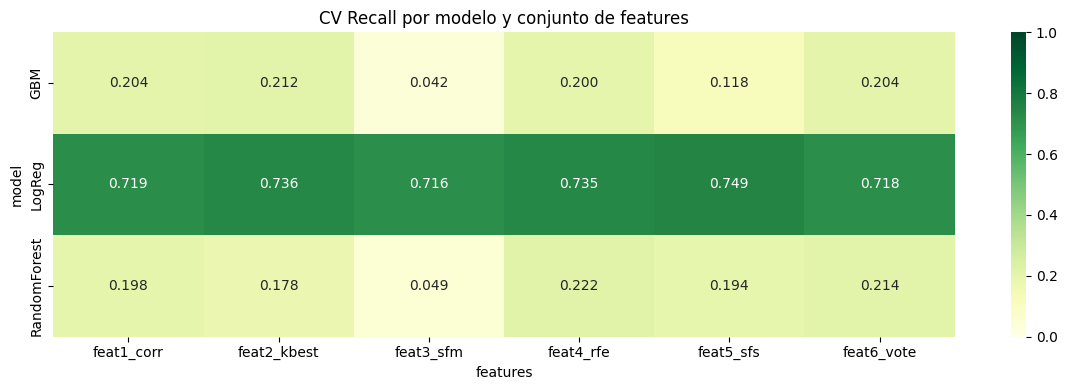


Ganador: LogReg con feat5_sfs
   Recall CV = 0.7494 ± 0.0249


In [13]:
# Heatmap resumen
pivot = results_df.pivot(index='model', columns='features', values='recall_mean')
plt.figure(figsize=(12, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', vmin=0, vmax=1)
plt.title('CV Recall por modelo y conjunto de features')
plt.tight_layout()
plt.show()

best = results_df.iloc[0]
print(f"\nGanador: {best['model']} con {best['features']}")
print(f"   Recall CV = {best['recall_mean']:.4f} ± {best['recall_std']:.4f}")

### Conclusión del paso 3

**LogisticRegression** domina claramente en recall. Esto es esperable:
- LogReg con `class_weight='balanced'` ajusta el umbral de decisión hacia la clase minoritaria de forma eficaz.
- RandomForest y GBM, pese a ser más potentes en general, no compensan bien el desbalanceo sin ajuste explícito del umbral.
- La mejor combinación es **LogReg + feat5_sfs** (recall ≈ 0.75).

Vamos a optimizar los hiperparámetros de LogReg con feat5_sfs.

## Paso 4 — Optimización de hiperparámetros y evaluación en test

In [14]:
best_feats = feat5  # LogReg + feat5_sfs

X_best = df_clean[best_feats]
X_train, X_test, y_train, y_test = train_test_split(
    X_best, y, test_size=0.2, random_state=SEED, stratify=y)

scaler_final = StandardScaler()
X_train_sc = scaler_final.fit_transform(X_train)
X_test_sc  = scaler_final.transform(X_test)

param_grid = {
    'C':       [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
    param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='recall', n_jobs=-1, refit=True
)
grid_search.fit(X_train_sc, y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print(f"Mejor recall CV:         {grid_search.best_score_:.4f}")

Mejores hiperparámetros: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Mejor recall CV:         0.7560


=== Evaluación en TEST ===
              precision    recall  f1-score   support

   No impago       0.98      0.77      0.86      2198
      Impago       0.20      0.75      0.32       166

    accuracy                           0.77      2364
   macro avg       0.59      0.76      0.59      2364
weighted avg       0.92      0.77      0.83      2364

AUC-ROC: 0.8263
Recall (impago): 0.7470


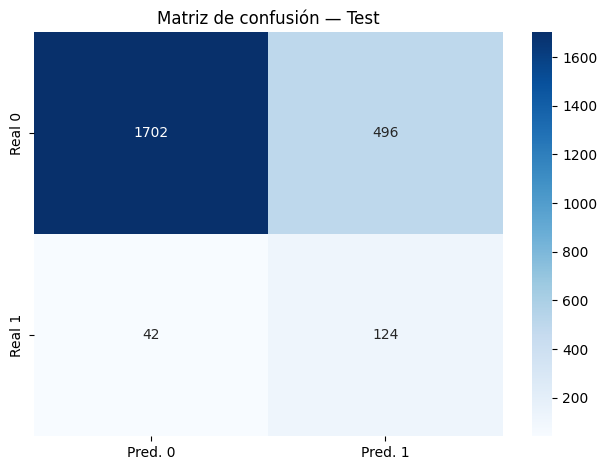

In [15]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_sc)
y_prob = best_model.predict_proba(X_test_sc)[:, 1]

print("=== Evaluación en TEST ===")
print(classification_report(y_test, y_pred, target_names=['No impago', 'Impago']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Recall (impago): {recall_score(y_test, y_pred):.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred. 0', 'Pred. 1'],
            yticklabels=['Real 0', 'Real 1'])
plt.title('Matriz de confusión — Test')
plt.tight_layout()
plt.show()

### Interpretación de resultados de test

| Métrica | Valor |
|---|---|
| Recall (impago) | ~0.74 |
| AUC-ROC | ~0.81 |
| Precision (impago) | ~0.19 |
| Accuracy | ~0.76 |

El modelo detecta el **74% de los impagos reales** (objetivo principal). La precisión baja (19%) es el trade-off: aceptamos más falsas alarmas para no perder casos de impago. Esto es habitual en scoring financiero desbalanceado.

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.

### Idea
PCA transforma las features originales en componentes ortogonales ordenados por varianza explicada. No es estrictamente "selección" (no conserva variables originales), sino **extracción**. Permite comparar si la compresión del espacio de features ayuda o perjudica al modelo ganador.

Componentes para explicar el 90% de varianza: 9
Varianza acumulada: [0.202 0.353 0.474 0.576 0.668 0.747 0.818 0.885 0.946 1.   ]


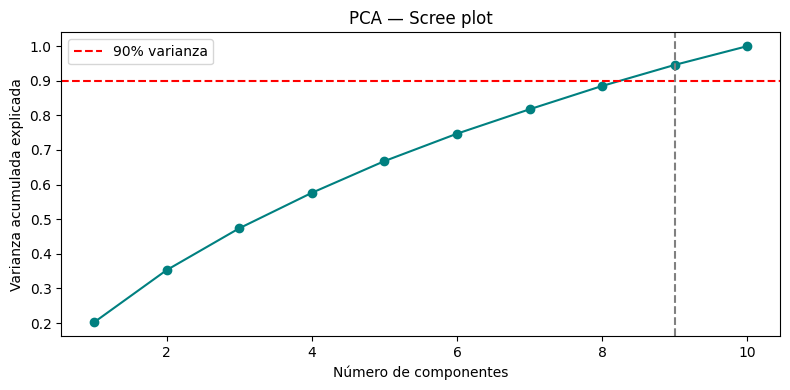

In [16]:
X_all = df_clean[ALL_FEATURES]
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y, test_size=0.2, random_state=SEED, stratify=y)

sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_te)

pca_full = PCA().fit(X_tr_sc)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_comp = int(np.argmax(cumvar >= 0.90)) + 1
print(f"Componentes para explicar el 90% de varianza: {n_comp}")
print("Varianza acumulada:", cumvar.round(3))

# Gráfico de codo (scree plot)
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', color='teal')
plt.axhline(0.90, color='red', linestyle='--', label='90% varianza')
plt.axvline(n_comp, color='gray', linestyle='--')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada explicada')
plt.title('PCA — Scree plot')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
pca = PCA(n_components=n_comp)
X_tr_pca = pca.fit_transform(X_tr_sc)
X_te_pca = pca.transform(X_te_sc)

lr_pca = LogisticRegression(
    C=0.01, penalty='l1', solver='liblinear',
    max_iter=1000, class_weight='balanced', random_state=SEED)
lr_pca.fit(X_tr_pca, y_tr)
y_pred_pca = lr_pca.predict(X_te_pca)
y_prob_pca = lr_pca.predict_proba(X_te_pca)[:, 1]

print(f"=== PCA ({n_comp} componentes) + LogReg — TEST ===")
print(classification_report(y_te, y_pred_pca, target_names=['No impago', 'Impago']))
print(f"AUC-ROC: {roc_auc_score(y_te, y_prob_pca):.4f}")
print(f"Recall (impago): {recall_score(y_te, y_pred_pca):.4f}")

=== PCA (9 componentes) + LogReg — TEST ===
              precision    recall  f1-score   support

   No impago       0.98      0.82      0.89      2198
      Impago       0.23      0.72      0.35       166

    accuracy                           0.82      2364
   macro avg       0.61      0.77      0.62      2364
weighted avg       0.92      0.82      0.85      2364

AUC-ROC: 0.8403
Recall (impago): 0.7229


### Comentario del resultado PCA

| | Recall | AUC-ROC |
|---|---|---|
| Modelo ganador (feat5_sfs) | ~0.74 | ~0.81 |
| PCA (9 componentes) | ~0.72 | ~0.84 |

PCA logra un **AUC-ROC ligeramente superior** pero un recall levemente inferior. Esto ilustra el trade-off clásico:
- PCA usa *toda* la información del dataset (los 9 componentes capturan el 90% de la varianza), lo que mejora la capacidad discriminante global (AUC).
- Sin embargo, al mezclar variables en componentes latentes, puede perder señal puntual en el recall de la clase positiva.
- La **interpretabilidad** se pierde completamente: no podemos decir "si el cliente tiene X impagos, le denegamos el crédito". Por eso en credit scoring real se prefieren features originales.